# LSTM model (Extracted Features)

**Reduced feature set (feature extraction using PCA)**

Author: Pete King

Here we test an LSTM model's ability to predict near-term volatility using a reduced set of features extracted from macroeconomic and other data, and compare results to the limited-feature and full-feature models.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 10  # No. timestamps in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df.head(SEQUENCE_LENGTH + 1)

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2015-10-15,0.007701,0.008268,-0.007520,-0.017314,-0.043684,-0.032462,-0.030379,-0.060332,-0.049247,-0.045121,-0.042721,-0.051108,-0.030138,-0.026966
2015-10-16,0.007959,0.009382,-0.035560,-0.031620,0.003971,-0.004365,-0.028710,-0.019565,-0.042536,-0.040873,-0.026386,-0.008257,-0.036894,-0.000262
2015-10-19,0.007951,0.009444,-0.024012,-0.029969,-0.043351,-0.038941,-0.035658,-0.048344,-0.050392,-0.037353,-0.043544,-0.024586,0.013132,-0.043831
2015-10-20,0.007453,0.009466,-0.037603,-0.007127,0.011081,0.006980,0.076445,0.080881,0.071050,-0.022265,-0.023854,-0.006707,-0.033878,-0.052647
2015-10-21,0.007660,0.010365,-0.068045,-0.069615,-0.046138,-0.056662,-0.043457,-0.030918,0.005319,0.010031,0.023756,0.088866,0.088049,0.062458
2015-10-22,0.008268,0.007168,0.050517,0.093730,0.074694,0.138572,0.129892,0.176194,0.160783,0.089222,0.096920,0.079977,0.067425,0.051895
2015-10-23,0.009382,0.005598,0.043751,0.035613,0.084277,0.096173,0.125774,0.134116,0.219914,0.240583,0.201113,0.279078,0.235231,0.177404
2015-10-26,0.009444,0.007602,0.145985,0.147558,0.157365,0.112709,0.122432,0.120424,0.099530,0.093639,0.105820,0.079622,0.071739,0.058124
2015-10-27,0.009466,0.007663,0.035296,0.041502,0.073764,0.064712,0.063965,0.048506,0.035312,0.030025,-0.017501,-0.032592,-0.044933,-0.049093


In [3]:
val_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2023-01-03,0.010149,0.012281,0.453148,0.416874,0.381460,0.326747,0.354667,0.360351,0.337249,0.291625,0.291295,0.358607,0.305738,0.317716
2023-01-04,0.010569,0.013061,0.311262,0.311023,0.294998,0.261813,0.240430,0.213455,0.250893,0.217927,0.185115,0.198519,0.206457,0.258115
2023-01-05,0.010334,0.012119,0.235466,0.230937,0.254731,0.296965,0.303737,0.282520,0.260512,0.297815,0.289761,0.382723,0.367265,0.349193
2023-01-06,0.012081,0.006860,0.388954,0.363824,0.384132,0.367676,0.377511,0.353356,0.390025,0.430805,0.401760,0.431728,0.521280,0.756046
2023-01-09,0.012026,0.006905,0.699941,0.724340,0.684554,0.786740,0.791232,0.633942,0.518006,0.575002,0.709899,0.622068,0.578389,0.536066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.006228,0.010568,0.269142,0.399398,0.442439,0.389765,0.436826,0.429588,0.436434,0.402734,0.451807,0.453731,0.566122,0.422984
2024-08-27,0.006215,0.010590,0.355401,0.331234,0.325219,0.329956,0.408022,0.455212,0.523947,0.572985,0.518424,0.351898,0.406411,0.301182
2024-08-28,0.006562,0.010323,0.360439,0.362614,0.350596,0.386493,0.407979,0.364291,0.368419,0.375473,0.376797,0.322327,0.410690,0.298640


## II. PyTorch Multivariate LSTM Model


### Create Datasets and DataLoaders

In [4]:
# Separate features from labels; discard daily returns as a feature. Note 
# that we capture recent returns (past 2-weeks) in one of the PCA features.
data_cols, label_col = dp.get_X_y_cols(train_df, returns=False)
X_train, y_train = train_df[data_cols].copy(), train_df[label_col].copy()
X_val, y_val = val_df[data_cols].copy(), val_df[label_col].copy()
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([10, 13])
Shape of first training label: torch.Size([1])


In [6]:
print(X_0)

tensor([[ 7.7006e-03, -7.5197e-03, -1.7314e-02, -4.3684e-02, -3.2462e-02,
         -3.0379e-02, -6.0332e-02, -4.9247e-02, -4.5121e-02, -4.2721e-02,
         -5.1108e-02, -3.0138e-02, -2.6966e-02],
        [ 7.9589e-03, -3.5560e-02, -3.1620e-02,  3.9711e-03, -4.3649e-03,
         -2.8710e-02, -1.9565e-02, -4.2536e-02, -4.0873e-02, -2.6386e-02,
         -8.2575e-03, -3.6894e-02, -2.6220e-04],
        [ 7.9508e-03, -2.4012e-02, -2.9969e-02, -4.3351e-02, -3.8941e-02,
         -3.5658e-02, -4.8344e-02, -5.0392e-02, -3.7353e-02, -4.3544e-02,
         -2.4586e-02,  1.3132e-02, -4.3831e-02],
        [ 7.4531e-03, -3.7603e-02, -7.1275e-03,  1.1081e-02,  6.9799e-03,
          7.6445e-02,  8.0881e-02,  7.1050e-02, -2.2265e-02, -2.3854e-02,
         -6.7068e-03, -3.3878e-02, -5.2647e-02],
        [ 7.6598e-03, -6.8045e-02, -6.9615e-02, -4.6138e-02, -5.6662e-02,
         -4.3457e-02, -3.0918e-02,  5.3187e-03,  1.0031e-02,  2.3756e-02,
          8.8866e-02,  8.8049e-02,  6.2458e-02],
        [ 8.268

In [7]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 10, 13])
Shape of first batch of labels: torch.Size([21, 1])


In [8]:
print(y_0)

tensor([0.0059])


### Instantiate and train LSTM model

Here we return to a reduced hidden layer size due to the smaller set of input features.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(13, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.0035650907084345818
Validation loss: 0.003033818444237113
Epoch 20
Training loss:   0.00483406987041235
Validation loss: 0.00747055746614933
Epoch 30
Training loss:   0.003265874460339546
Validation loss: 0.005247976165264845
Epoch 40
Training loss:   0.002019268460571766
Validation loss: 0.003477478167042136
Epoch 50
Training loss:   0.002065199427306652
Validation loss: 0.004180752672255039
Epoch 60
Training loss:   0.0016312478110194206
Validation loss: 0.003291073953732848
Epoch 70
Training loss:   0.001296953298151493
Validation loss: 0.003024519421160221
Epoch 80
Training loss:   0.002488083206117153
Validation loss: 0.004122965969145298
Epoch 90
Training loss:   0.00286026019603014
Validation loss: 0.004524434916675091
Epoch 100
Training loss:   0.0033367807045578957
Validation loss: 0.004013479687273502


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


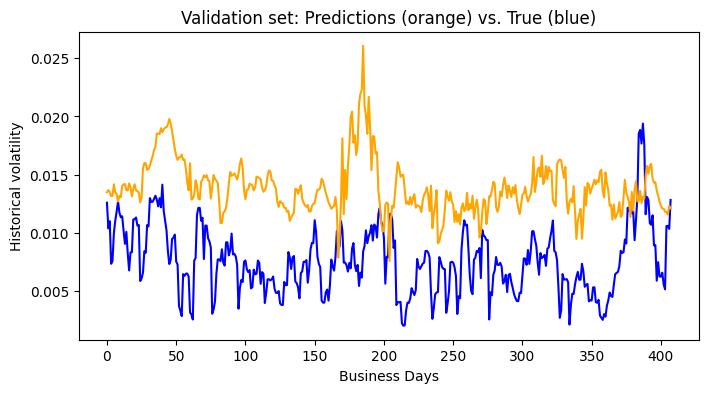

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')

It's not entirely clear whether the extracted features provide an overall benefit to the model.  Compared to the model with limited input (only return and volatility for the ETF in question), this model is less consistent.  Sometimes the forecast is very spot-on, but other times it misjudges what the market will do and goes in the wrong direction.  Whereas the limited-input model was consistently biased but also tracked consistently with the contours of future volatility figures.

In [15]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds) - 0.0058)}')

R2: -0.5014824867248535
MAE: 0.0027595015708357096
RMSE: 0.0035192423965781927
MSE: 1.2385066838760395e-05
